<center><h1>small sample analysis</h1></center>
<center><h3>yurii liudomyrskyi</h3></center>


## imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from math import exp, factorial, comb, ceil, floor, sqrt, log2

from scipy.stats import chi2

## stylisation

### font parameters

In [2]:
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16

### graphs style 

In [3]:
def apply_plot_style(fig, ax):
    ax.spines["bottom"].set_color("#669999")
    ax.spines["left"].set_color("#669999")
    ax.spines["top"].set_color("#669999")
    ax.spines["right"].set_color("#669999")

    ax.grid(True, color="#b3d9d1", linestyle="--", linewidth=0.8)

    ax.set_facecolor("#f0ffff")
    fig.set_facecolor("#e1fffa")

## functions for visualisation

### empirical cumulative distribution function

In [4]:
def ecdf(cdf_values):
    fig, ax = plt.subplots(1, 1, figsize=(13, 6))
    mako = sns.color_palette("mako", len(cdf_values) + 2)

    x = list(range(len(cdf_values)))

    ax.hlines(0, -0.5, 0, color=mako[0], linewidth=3.0)

    for i, val in enumerate(cdf_values):
        ax.hlines(val, i, i + 1, color=mako[i+1], linewidth=3.0)

    prev = 0
    for i, val in enumerate(cdf_values):
        ax.vlines(i, prev, val, color=mako[i+1], linestyle="--", alpha=0.85, linewidth=2.0)
        prev = val

    ax.plot([i + 0.01 for i in x], cdf_values, linestyle="None", marker="<", markersize=7, color=mako[-1])

    apply_plot_style(fig, ax)
    ax.set_xlim(-0.5, len(cdf_values))
    ax.set_ylim(-0.05, 1.05)

    plt.xlabel(r"$x$")
    plt.ylabel(r"$F_n^*(x)$")
    plt.title("empirical cumulative distribution function")

    plt.tight_layout()
    plt.savefig("..\\figures\\cdf.png")
    plt.show()

### boxplot

In [5]:
def boxplot(sample):
    fig, ax = plt.subplots(1, 1, figsize=(13, 3))
    mako = sns.color_palette("mako", 6)

    bp = ax.boxplot(sample, patch_artist=True, vert=False, widths=0.45)

    for patch in bp['boxes']:
        patch.set_facecolor(mako[2])
        patch.set_edgecolor(mako[4])
        patch.set_linewidth(2)

    for whisker in bp['whiskers']:
        whisker.set(color=mako[4], linewidth=2, linestyle="--")

    for cap in bp['caps']:
        cap.set(color=mako[4], linewidth=2)

    for median in bp['medians']:
        median.set(color=mako[5], linewidth=3)

    for flier in bp['fliers']:
        flier.set(marker='o', color=mako[5], alpha=0.6, markersize=6)

    apply_plot_style(fig, ax)
    ax.set_yticks([])

    plt.xlabel("values")
    plt.title("boxplot")

    plt.tight_layout()
    plt.savefig("..\\figures\\boxplot.png")
    plt.show()

### probability mass function comparison

In [6]:
def pmfs(sample):
    fig, ax = plt.subplots(1, 1, figsize=(13, 6))
    mako = sns.color_palette("mako", 6)

    sample_values, sample_counts = np.unique(sample, return_counts=True)
    rel_freq = sample_counts / len(sample)

    x = np.arange(sample_values.min(), sample_values.max()+1)

    lam = sample.mean()
    p_geom = 1/(1+sample.mean())
    n_bin = 3
    p_bin = sample.mean()/n_bin

    poisson_pmf = np.array([exp(-lam)*lam**m/factorial(m) for m in x])
    geometric_pmf = np.array([p_geom*(1-p_geom)**m for m in x])
    binomial_pmf = np.array([comb(n_bin,m)*(p_bin**m)*(1-p_bin)**(n_bin-m) for m in x])

    ax.bar(sample_values, rel_freq, width=0.2, color=mako[2], edgecolor=mako[4], linewidth=1.8, alpha=0.8, label="relative frequencies")

    ax.plot(x, poisson_pmf, 'o--', color=mako[5], linewidth=2, markersize=6, label=fr'poisson ($\lambda={lam:.2f}$)')
    ax.plot(x, geometric_pmf, 's--', color=mako[4], linewidth=2, markersize=6, label=fr'geom ($p={p_geom:.2f}$)')
    ax.plot(x, binomial_pmf, 'd--', color=mako[3], linewidth=2, markersize=6, label=fr'bin ($n={n_bin}, p={p_bin:.2f}$)')

    apply_plot_style(fig, ax)
    ax.set_xlabel("observed value")
    ax.set_ylabel("probability / frequency")
    ax.set_xticks(x)
    ax.set_title("observed frequencies vs fitted pmf")

    legend = ax.legend(frameon=True)
    legend.get_frame().set_facecolor("#f0ffff")
    legend.get_frame().set_edgecolor("#669999")

    plt.tight_layout()
    plt.savefig("..\\figures\\dists.png", dpi=300)
    plt.show()

## key analysis

### exploration

In [7]:
sample_array = np.loadtxt("..\data\sample.csv", delimiter=",", dtype=int)
sample_array

array([1, 1, 0, 0, 2, 0, 0, 0, 0, 2, 2, 0, 0, 3, 2, 0, 0, 1, 2, 1, 0, 0,
       0, 0, 0, 2, 0, 0, 3, 3, 1, 0, 1, 3, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2,
       1, 2, 1, 1, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 3, 0, 1, 2, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0])

In [8]:
sample_array.shape

(100,)

In [9]:
sample_length = len(sample_array)

### frequencies

In [10]:
values, counts = np.unique(sample_array, return_counts=True)

for v, c in zip(values, counts):
    print(f"value {v}: {c}", end="    ")

freqs = counts / len(sample_array)
freqs

value 0: 62    value 1: 21    value 2: 12    value 3: 5    

array([0.62, 0.21, 0.12, 0.05])

In [11]:
c_freqs = np.cumsum(freqs)
c_freqs

array([0.62, 0.83, 0.95, 1.  ])

### cumulative distribution function

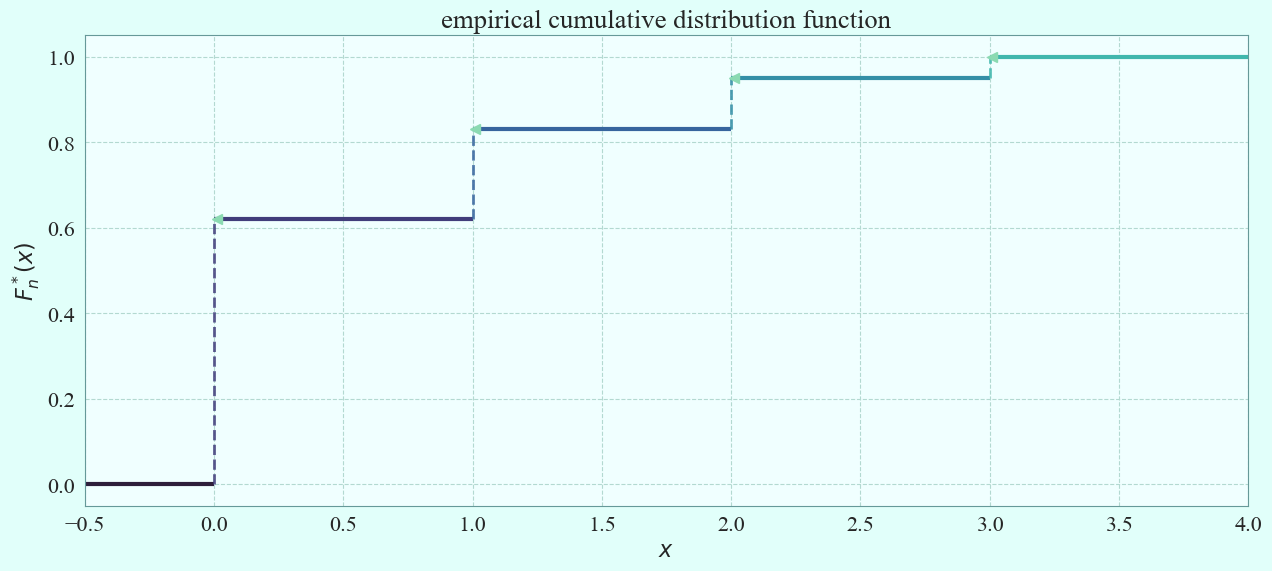

In [12]:
ecdf(c_freqs)

### boxplot

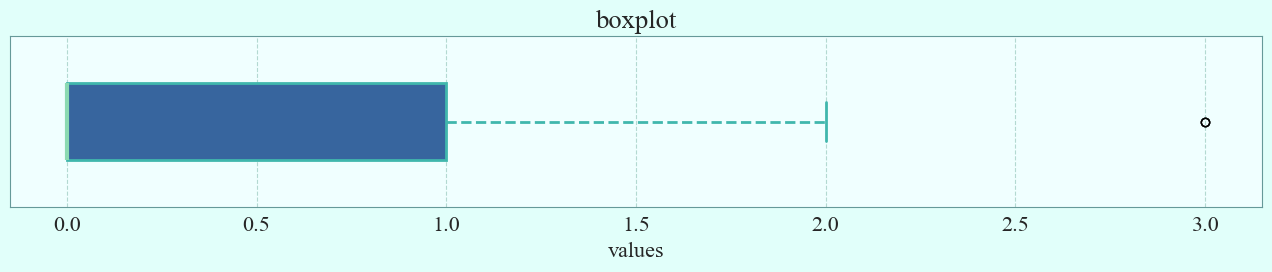

In [13]:
boxplot(sample_array)

### mean, variance, skewness, and kurtosis

In [14]:
sample_mean = np.sum(sample_array) / len(sample_array)
sample_mean

0.6

In [15]:
sample_variance = np.var(sample_array)
sample_variance

0.7799999999999998

In [16]:
corrected_variance = np.var(sample_array, ddof=1)
corrected_variance

0.7878787878787877

In [17]:
def compute_skewness(x, freedom=0):
    x = np.asarray(x)
    return np.mean((x - np.mean(x))**3) / (np.var(x, ddof=freedom)**1.5)

In [18]:
def compute_kurtosis(x, freedom=0):
    x = np.asarray(x)
    return np.mean((x - np.mean(x))**4) / (np.var(x, ddof=freedom)**2) - 3


In [19]:
compute_kurtosis(sample_array, 0)

0.6252465483234739

In [20]:
compute_kurtosis(sample_array, 1)

0.5531041420118363

In [21]:
compute_skewness(sample_array, 0)

1.3064735009360724

In [22]:
compute_skewness(sample_array, 1)

1.286925473140655

## parameters estimation

### binomial distribution

In [23]:
class BinomialDistributionEstimator:
    def __init__(self, x, n_trials=None):
        self.x = np.asarray(x)
        self.n_trials = n_trials if n_trials is not None else int(np.max(self.x))
    
    def estimate_parameters(self):
        p = np.mean(self.x) / self.n_trials
        
        mean = np.mean(self.x)
        variance = self.n_trials * p * (1 - p)
        median = [floor(self.n_trials * p) - 1, floor(self.n_trials * p), floor(self.n_trials * p) + 1]
        mode = floor((self.n_trials + 1) * p)
        skewness = (1 - 2*p) / (sqrt(self.n_trials * p * (1-p)))
        kurtosis = (1 - 6 * p * (1 - p)) / (self.n_trials * p * (1-p))
        
        return {"n": self.n_trials, "p": p, "mean" : mean, "v": variance, "me": median, "mo": mode, "as" : skewness, "ek" : kurtosis}
    
    def pmf(self, k):
        p = np.mean(self.x) / self.n_trials
        return comb(self.n_trials, k) * (p ** k) * ((1 - p) ** (self.n_trials - k))
    
    def pmf_array(self, support=None):
        if support is None:
            support = np.arange(0, self.n_trials + 1)
        return np.array([self.pmf(k) for k in support])

In [24]:
binomial_estimator = BinomialDistributionEstimator(sample_array)
binomial_estimator.estimate_parameters()

{'n': 3,
 'p': 0.19999999999999998,
 'mean': 0.6,
 'v': 0.48,
 'me': [-1, 0, 1],
 'mo': 0,
 'as': 0.8660254037844388,
 'ek': 0.08333333333333341}

### poisson distribution

In [25]:
class PoissonDistributionEstimator:
    def __init__(self, x):
        self.x = np.asarray(x)

    def estimate_parameters(self):
        lam = np.mean(self.x)

        mean = lam
        variance = lam
        median = ceil(lam + 1/3 - 0.02*lam) 
        mode = floor(lam)
        skewness = 1 / sqrt(lam) 
        kurtosis = 1 / lam 

        return {"lambda": lam, "mean": mean, "v": variance, "me": median, "mo": mode, "as": skewness, "ek": kurtosis}

    def pmf(self, k):
        lam = np.mean(self.x)
        return exp(-lam) * lam**k / factorial(k)

    def pmf_array(self, support=None):
        if support is None:
            support = np.arange(0, np.max(self.x) + 1)
        return np.array([self.pmf(k) for k in support])

In [26]:
poisson_estimator = PoissonDistributionEstimator(sample_array)
poisson_estimator.estimate_parameters()

{'lambda': 0.6,
 'mean': 0.6,
 'v': 0.6,
 'me': 1,
 'mo': 0,
 'as': 1.2909944487358056,
 'ek': 1.6666666666666667}

### geometric distribution

In [27]:
class GeometricDistributionEstimator:
    def __init__(self, x):
        self.x = np.asarray(x)

    def estimate_parameters(self):
        p = 1 / (np.mean(self.x) + 1)
        
        mean = np.mean(self.x)
        variance = (1 - p) / p**2
        median = floor((-1) / (log2(1 - p)))
        mode = 0
        skewness = (2 - p) / (sqrt(1 - p))
        kurtosis = 6 + (p**2) / (1 - p)

        return {"p": p, "mean": mean, "v": variance, "me": median, "mo": mode, "as": skewness, "ek": kurtosis}

    def pmf(self, k):
        p = 1 / (np.mean(self.x) + 1)
        q = 1 - p
        return p * (q ** k)


    def pmf_array(self, support=None):
        if support is None:
            support = np.arange(0, np.max(self.x) + 1)
        return np.array([self.pmf(k) for k in support])

In [28]:
geometric_estimator = GeometricDistributionEstimator(sample_array)
geometric_estimator.estimate_parameters()

{'p': 0.625,
 'mean': 0.6,
 'v': 0.96,
 'me': 0,
 'mo': 0,
 'as': 2.2453655975512468,
 'ek': 7.041666666666667}

### visualisation of the probability mass functions 

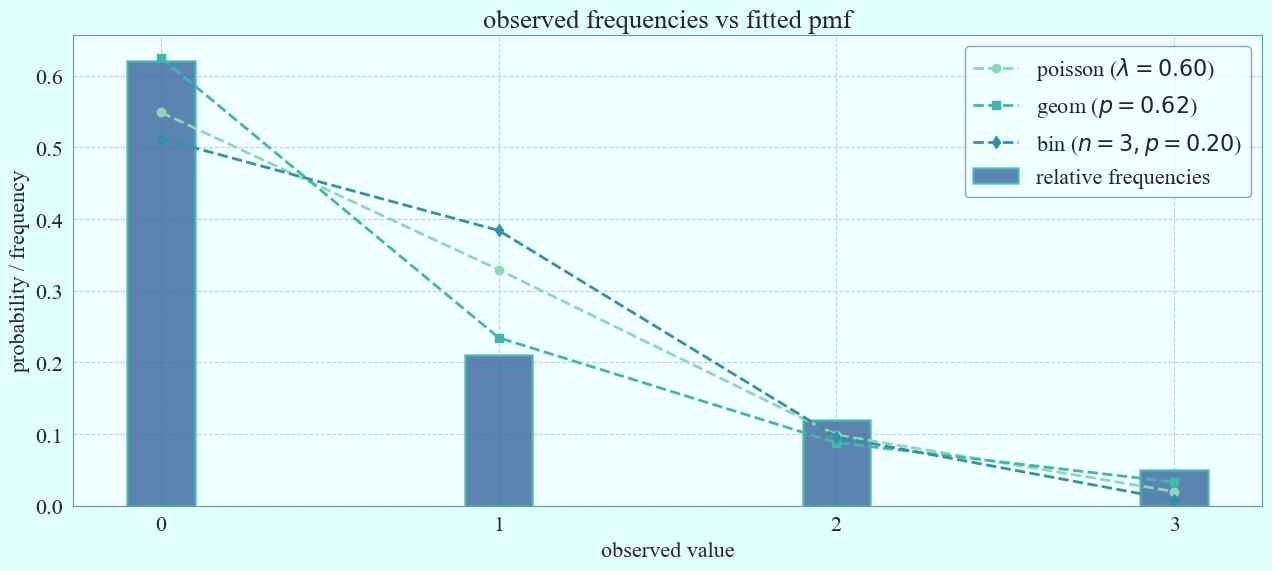

In [29]:
pmfs(sample_array)

## confidence intervals computation

### poisson distribution intervals

In [30]:
def poisson_cint(sample, parameter, t):
    n = len(sample)
    left  = parameter + ((t**2) / (2*n)) - t*np.sqrt((parameter / n) + ((t**2) / (4*n**2)))
    right = parameter + ((t**2) / (2*n)) + t*np.sqrt((parameter / n) + ((t**2) / (4*n**2)))
        
    return left, right

In [31]:
poisson_cint(sample_array, 0.6, 1.96)

(0.4661768029714202, 0.7722391970285798)

### geometric distribution intervals

In [32]:
def geom_cint(sample, parameter, t):
    n = len(sample)
    left  = (2 * parameter + ((t**2) / n) - np.sqrt((t ** 2 / n) + ((4 * parameter * (parameter + 1)) / n))) / (2 * (1 - t ** 2 / n))
    right = (2 * parameter + ((t**2) / n) + np.sqrt((t ** 2 / n) + ((4 * parameter * (parameter + 1)) / n))) / (2 * (1 - t ** 2 / n))
    
    return left, right

In [33]:
geom_cint(sample_array, 0.6, 1.96)

(0.49983101048836076, 0.7880606349633106)

## chi-square testing

### poisson hypothesis

<center>$$H_0: \xi \sim Pois(\lambda)$$</center>


In [34]:
obs = np.array([
    np.sum(sample_array == 0),
    np.sum(sample_array == 1),
    np.sum(sample_array >= 2)
])

p0 = poisson_estimator.pmf(0)
p1 = poisson_estimator.pmf(1)
p_ge2 = 1 - p0 - p1

exp_counts = np.array([
    sample_length * p0,
    sample_length * p1,
    sample_length * p_ge2
])

chi_stat = np.sum((obs - exp_counts)**2 / exp_counts)
dof = 3 - 1 - 1

print("observed values:", obs)
print("expected counts:", exp_counts)
print("сhi-square statistic:", chi_stat)
print("p-value:", 1 - chi2.cdf(chi_stat, dof))

observed values: [62 21 17]
expected counts: [54.88116361 32.92869817 12.19013822]
сhi-square statistic: 7.142508385533879
p-value: 0.007527778990467637


In [35]:
chi_manual = 0

for l in range(len(obs)):
    contribution = (obs[l] - exp_counts[l])**2 / exp_counts[l]
    print(
        f"bin {l}: observed = {obs[l]}, expected = {exp_counts[l]:.6f}, "
        f"contribution = {contribution:.6f}"
    )
    chi_manual += contribution

print("manual chi-square statistic:", chi_manual)
print("p-value:", 1 - chi2.cdf(chi_manual, dof))

bin 0: observed = 62, expected = 54.881164, contribution = 0.923410
bin 1: observed = 21, expected = 32.928698, contribution = 4.321271
bin 2: observed = 17, expected = 12.190138, contribution = 1.897827
manual chi-square statistic: 7.142508385533879
p-value: 0.007527778990467637


### geometric hypothesis

<center>$$H_0: \xi \sim Geom_0(p)$$</center>


In [36]:
obs = np.array([
    np.sum(sample_array == 0),
    np.sum(sample_array == 1),
    np.sum(sample_array == 2),
    np.sum(sample_array >= 3)
])

p0 = geometric_estimator.pmf(0)
p1 = geometric_estimator.pmf(1)
p2 = geometric_estimator.pmf(2)
p_ge3 = 1 - p0 - p1 - p2

exp_counts = np.array([
    sample_length * p0,
    sample_length * p1,
    sample_length * p2,
    sample_length * p_ge3
])

chi_stat = np.sum((obs - exp_counts)**2 / exp_counts)
dof = 4 - 1 - 1

print("observed values:", obs)
print("expected counts:", exp_counts)
print("сhi-square statistic:", chi_stat)
print("p-value:", 1 - chi2.cdf(chi_stat, dof))

observed values: [62 21 12  5]
expected counts: [62.5       23.4375     8.7890625  5.2734375]
сhi-square statistic: 1.4447407407407407
p-value: 0.48559983920158856


In [37]:
chi_manual = 0

labels = ["0", "1", "2", ">=3"]

for l in range(len(obs)):
    contribution = (obs[l] - exp_counts[l])**2 / exp_counts[l]
    print(
        f"bin {labels[l]}: observed = {obs[l]}, expected = {exp_counts[l]:.6f}, "
        f"contribution = {contribution:.6f}"
    )
    chi_manual += contribution

print("manual chi-square statistic:", chi_manual)

print("p-value:", 1 - chi2.cdf(chi_manual, dof))

bin 0: observed = 62, expected = 62.500000, contribution = 0.004000
bin 1: observed = 21, expected = 23.437500, contribution = 0.253500
bin 2: observed = 12, expected = 8.789062, contribution = 1.173062
bin >=3: observed = 5, expected = 5.273438, contribution = 0.014178
manual chi-square statistic: 1.4447407407407407
p-value: 0.48559983920158856


### chi-square statistic values

#### significance level alpha = 0.05, dof = 1

In [38]:
chi2.ppf(1 - 0.05, 1)

3.841458820694124

#### significance level alpha = 0.01, dof = 1

In [39]:
chi2.ppf(1 - 0.01, 1)

6.6348966010212145

#### significance level alpha = 0.05, dof = 2

In [40]:
chi2.ppf(1 - 0.05, 2)

5.991464547107979

#### significance level alpha = 0.01, dof = 2

In [41]:
chi2.ppf(1 - 0.01, 2)

9.21034037197618